<img src="https://cdn.jsdelivr.net/gh/hellsdeur/gendl/images/banner.png" alt="Banner" width="100%">

- Curso: PPG em Genética e Biologia Molecular (PPGBM-UFPA)
- Disciplina: IA na Descoberta Genética
- Tema: Deep Learning para Genômica
- Docente: Helder Matos e Sintia Almeida

# 0. Preliminares

## 0.1. Ambiente de desenvolvimento: Notebooks

Um Notebook é um formato de caderno de notas que roda no navegador. Serve para desenvolver, colaborar e publicar projetos de ciência e mineração de dados.

Um notebook tem pelo menos dois tipos de célula:

- **Código:** executa scripts em Python (dá para usar outras linguagens também)
- **Markdown:** texto formatado, para documentar e organizar o raciocínio

<div style="text-align: center;">
    <img src="https://cdn.jsdelivr.net/gh/hellsdeur/gendl/images/notebook.png" alt="Interface genérica de uma aplicação para Notebooks" width="800">
</div>

Esta célula atual (e todas as anteriores) é uma célula de markdown.

In [47]:
# Esta célula atual é uma célula de código Python.

for i in range(10):
    if i % 2 == 0:
        print(f"{i} é par")
    else:
        print(f"{i} é ímpar")

0 é par
1 é ímpar
2 é par
3 é ímpar
4 é par
5 é ímpar
6 é par
7 é ímpar
8 é par
9 é ímpar


Um notebook pode rodar de forma local ou na nuvem.

- **Local:** usa a máquina do usuário. Exige instalação via Pip ou Conda.
- **Nuvem:** roda em um serviço externo, sem instalação. Exemplos: Google Colab, Kaggle Kernels, Azure Notebooks.

Vamos usar o **Google Colab** nesta aula.

## 0.2. Estrutura da aula

1. [Fundamentos de Deep Learning](#fundamentos-dl): apresenta o vocabulário mínimo de deep learning.
2. [Pré-processamento de dados](#pre-processamento): apresenta o estudo de caso e problema que guiam a aula.
3. [Balanceamento de classes](#balanceamento-classes): mostra a proporção de classes do problema.
4. [Regressão logística](#regressao-logistica): demonstra o modelo baseline.
5. [Redes neurais convolucionais](#redes-convolucionais): demonstra um modelo que reconhece características e vizinhanças.
6. [Redes neurais recorrentes](#redes-recorrentes): demonstra um modelo que reconhece memória e ordem das sequências.
7. [PyTorch e modelos do estado da arte](#pytorch-estado-arte): mostra o padrão de apresentação de modelos em artigos e uma pesquisa recente no tema.

# 1. Fundamentos de Deep Learning <a id="fundamentos-dl"></a>

Esta aula resolve um problema de genômica com deep learning. Antes do problema, vale dizer o que o termo significa, porque ele circula junto com outros dois e os três costumam ser tratados como sinônimos.

<div style="text-align: center;">
    <img src="https://cdn.jsdelivr.net/gh/hellsdeur/gendl/images/ia-ml-dl.png" alt="Inteligência artificial, aprendizado de máquina e deep learning, em três conjuntos aninhados" width="620">
</div>

A inteligência artificial é o campo mais amplo, e a definição mais antiga ainda é a mais útil: automatizar tarefas que normalmente exigiriam uma pessoa. Boa parte da IA feita até os anos 1980 não aprendia nada. Eram regras escritas à mão por especialistas, o que funcionou bem para xadrez e mal para quase tudo que depende de percepção.

O aprendizado de máquina é o subconjunto em que as regras deixam de ser escritas e passam a ser encontradas.

| | entra | sai |
|---|---|---|
| programação clássica | regras e dados | respostas |
| aprendizado de máquina | dados e respostas | regras |

Deep learning é o subconjunto do aprendizado de máquina em que essas regras são encontradas por uma pilha de camadas, cada uma transformando o dado um pouco mais que a anterior. O "deep" não indica profundidade de entendimento. Indica quantidade de camadas empilhadas.

O problema que vamos atacar é encontrar sítios de splice no genoma do cupuaçu. Existe uma regra clássica para isso, conhecida em biologia molecular há décadas, e a seção 2 vai medir o quanto ela não resolve.

O que vamos fazer é entregar milhares de sítios já anotados a um modelo e deixar que ele encontre a regra sozinho. O trabalho intelectual muda de lugar: em vez de descrever o sinal biológico, passamos a escolher que tipo de estrutura o modelo tem permissão de procurar.

Uma rede neural é essa pilha de camadas, e cada camada é uma transformação do dado. O que uma camada faz está guardado nos seus pesos, que são simplesmente números.

Aprender, nesse contexto, significa encontrar valores de peso que levem os exemplos de entrada aos rótulos certos. É só isso que o treino modifica. A arquitetura, ou seja, quantas camadas existem e de que tipo elas são, é escolhida por quem monta o modelo e permanece fixa durante o treino.

<img src="https://cdn.jsdelivr.net/gh/hellsdeur/gendl/images/nn.png" width="860">

Existem dois conceitos relacionados com a descoberta dos pesos e a qualidade dessa tarefa:
- A **função de perda** compara a predição do modelo com o rótulo verdadeiro e devolve um número que mede o tamanho do erro naquele exemplo.
- O **otimizador** toma esse número como sinal de realimentação e empurra cada peso um pouco na direção que diminui a perda.

No início os pesos são sorteados e o modelo responde qualquer coisa, com perda alta. A cada exemplo processado os pesos se ajustam um pouco, a perda cai, e esse ciclo repetido muitas vezes é o laço de treino. Uma passagem completa pelo conjunto de treino chama-se época.

Guarde os três nomes, porque eles voltam escritos no código: na seção 5 eles aparecem como os argumentos `loss`, `optimizer` e `epochs` de uma chamada, e o número de épocas vira o maior custo da seção 6.

Uma última ideia antes de começar, cada arquitetura carrega uma suposição sobre como o dado está organizado. Um modelo linear supõe que cada posição da sequência é independente das outras. Uma rede convolucional supõe que o que importa é a vizinhança. Uma rede recorrente supõe que importa a ordem em que se lê.

Nenhuma das três é melhor em abstrato. Vence a que assume sobre o dado alguma coisa que o dado de fato cumpre, e é isso que vamos testar, um degrau de cada vez.

Por essa razão a aula começa pelo dado, na próxima seção, e não pelo modelo.

# 2. Pré-processamento de dados <a id="pre-processamento"></a>

Vamos transformar um dado bruto em estruturas apropriadas para tarefas de Deep Learning. De sequência de DNA, que é texto, para tensor, que é número.

Ao final desta seção teremos um array de forma `(55001, 201, 4)`, com cada número carregando um significado biológico preciso.

## 2.1. Dados do genoma do cupuaçu

O cupuaçu (*Theobroma grandiflorum*) é uma árvore frutífera amazônica, parente
próxima do cacau.

<img src="https://cdn.jsdelivr.net/gh/hellsdeur/gendl/images/cupuacu.jpg" width="620">

Genoma montado telômero-a-telômero, publicado em
[Alves et al., *GigaScience* 13:giae027, 2024](https://pubmed.ncbi.nlm.nih.gov/38837946/). Os dados ficam no
GigaDB, no [conjunto 102523](https://gigadb.org/dataset/102523), distribuídos em dois arquivos:

- um **FASTA** com a sequência dos 10 cromossomos, 424 Mb no total;
- um **GFF3** com a anotação, que diz onde estão os genes, os éxons e os
  íntrons.

## 2.2. Extração das janelas

Esses dois arquivos não servem direto para treinar. Antes, eles passam por um processo que recorta pedaços de sequência e decide quais são sítio doador.

Esse processo rodou uma vez, fora da aula, e o resultado é o arquivo que a próxima subseção carrega. Vale entender como ele funciona, porque é daqui que saem os rótulos: a afirmação de que uma janela é ou não um sítio real vem daqui, e não de outro lugar.

O **sítio doador** é a fronteira onde um íntron começa. A subseção 2.4 mostra isso com base nos dados, mas por enquanto basta saber que é uma posição específica do genoma, e que a anotação diz onde cada uma está.

<img src="https://cdn.jsdelivr.net/gh/hellsdeur/gendl/images/extraction.png" width="1500">

O código que realiza essa etapa pode ser encontrado em [https://github.com/hellsdeur/gendl/blob/main/scripts/extract.py](https://github.com/hellsdeur/gendl/blob/main/scripts/extract.py). Optamos por não explorar esse trecho na aula devido ao tempo limitado e objetivo centrado na apresentação dos modelos, mas vale mencionar que cerca de [80% do trabalho de um cientista de dados se concentra nessa etapa](https://www.forbes.com/sites/gilpress/2016/03/23/data-preparation-most-time-consuming-least-enjoyable-data-science-task-survey-says/).

## 2.3. Carregamento dos dados

Com o processo entendido, o arquivo deixa de ser uma caixa-preta. A célula abaixo baixa os 15 MB na primeira execução. Rodando local, ela só usa o arquivo que já está na pasta.

In [ ]:
import json
import urllib.request
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

URL_DADOS = "https://github.com/hellsdeur/gendl/raw/refs/heads/main/data/splice_donor.npz"
CAMINHO_DADOS = Path("data/splice_donor.npz")

# Rodando local o arquivo já está aqui. No Colab, baixa na primeira execução.
if not CAMINHO_DADOS.exists():
    print("Baixando splice_donor.npz, 15 MB...")
    CAMINHO_DADOS.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(URL_DADOS, CAMINHO_DADOS)

# Um .npz é um zip, e todo zip começa com os bytes "PK". Se o download trouxe
# outra coisa, como uma página de erro, é melhor parar aqui com uma mensagem
# clara do que quebrar adiante com um erro do numpy.
if CAMINHO_DADOS.read_bytes()[:2] != b"PK":
    CAMINHO_DADOS.unlink()
    raise RuntimeError(f"O download não trouxe um .npz. Confira a URL:\n{URL_DADOS}")

dados = np.load(CAMINHO_DADOS)

# O .npz carrega junto um dicionário de metadados, gravado pelo script de
# extração. É de lá que vêm todos os números citados nesta seção: nenhum
# deles está digitado à mão no notebook.
meta = json.loads(str(dados["meta"]))
genoma = meta["genome_stats"]


def br(numero, casas=0):
    """Formata no padrão brasileiro: 1234567 -> 1.234.567 e 9.09 -> 9,09"""
    
    texto = f"{numero:,.{casas}f}"
    return texto.replace(",", "\x00").replace(".", ",").replace("\x00", ".")


print(f"Pares de base:      {br(genoma['genome_bp'])}")
print(f"Cromossomos:        {genoma['n_chromosomes']}")
print(f"Genes anotados:     {br(genoma['annotated_genes'])}")
print(f"Íntrons anotados:   {br(genoma['annotated_introns'])}")

Pares de base:      423.916.809
Cromossomos:        10
Genes anotados:     37.454
Íntrons anotados:   119.378


## 2.4. Problema de encontrar sítios doadores em genomas

Um gene não vira proteína diretamente:

1. o gene é transcrito em RNA;
2. esse RNA tem **éxons**, que permanecem, e **íntrons**, que são removidos;
3. cortar os íntrons e emendar os éxons é o **splicing**.

<img src="https://cdn.jsdelivr.net/gh/hellsdeur/gendl/images/genoma.png" width="900">

O **sítio doador** é a fronteira onde um íntron começa, e é ele que vamos prever.

Quase todo íntron começa com `GT`. O problema é que `GT` é um par de bases banal, e ele aparece em qualquer lugar do genoma.

<img src="https://cdn.jsdelivr.net/gh/hellsdeur/gendl/images/genoma-2.png" width="960">

Seis `GT` em um trecho curto, e só um deles é sítio doador. Quantos existem no genoma inteiro?

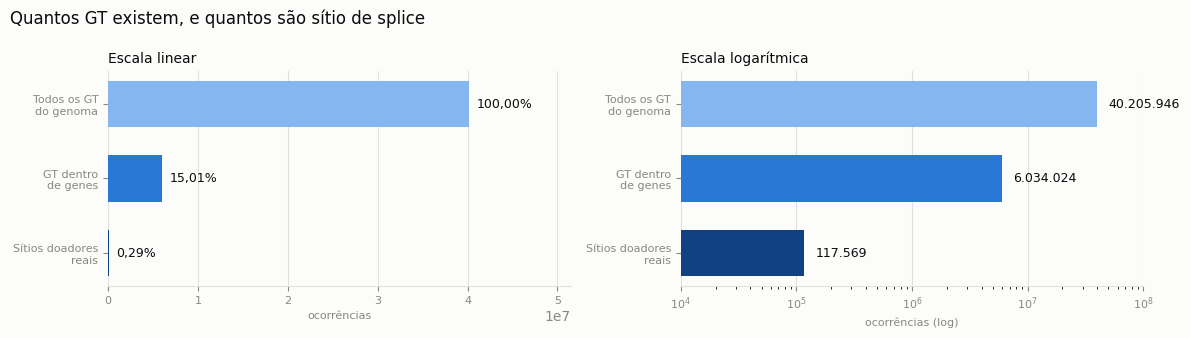

Íntrons que começam com GT: 117.569 de 119.378, ou 98,48%

No genoma inteiro:  1 sítio real a cada 342 GT
Dentro de genes:    1 sítio real a cada 51 GT


In [ ]:
# Contagens sobre o genoma INTEIRO, calculadas pelo script de extração.
grupos = [
    ("Todos os GT\ndo genoma", genoma["gt_genome_wide"]),
    ("GT dentro\nde genes", genoma["gt_in_gene_bodies"]),
    ("Sítios doadores\nreais", genoma["donor_sites"]),
]
rotulos = [nome for nome, _ in grupos]
valores = [valor for _, valor in grupos]

# Rampa sequencial de um único tom: os três grupos são subconjuntos aninhados
# da mesma medida, do mais geral (claro) ao mais específico (escuro).
CORES = ["#86b6ef", "#2a78d6", "#104281"]
SUPERFICIE, TINTA, MUTED, GRADE = "#fcfcfb", "#0b0b0b", "#898781", "#e1e0d9"

figura, eixos = plt.subplots(1, 2, figsize=(12, 3.4), facecolor=SUPERFICIE)
posicao = range(len(grupos))

for indice, eixo in enumerate(eixos):
    eixo.barh(posicao, valores, color=CORES, height=0.62)
    eixo.set_yticks(posicao)
    eixo.set_yticklabels(rotulos, fontsize=9, color=TINTA)
    eixo.invert_yaxis()
    eixo.set_facecolor(SUPERFICIE)
    eixo.xaxis.grid(True, color=GRADE, linewidth=0.8)
    eixo.set_axisbelow(True)
    for lado in ("top", "right", "left"):
        eixo.spines[lado].set_visible(False)
    eixo.spines["bottom"].set_color(GRADE)
    eixo.tick_params(colors=MUTED, labelsize=8)

eixos[0].set_title("Escala linear", fontsize=10, color=TINTA, loc="left")
eixos[0].set_xlabel("ocorrências", fontsize=8, color=MUTED)
eixos[0].set_xlim(0, max(valores) * 1.28)

eixos[1].set_xscale("log")
eixos[1].set_xlim(1e4, 1e8)
eixos[1].set_title("Escala logarítmica", fontsize=10, color=TINTA, loc="left")
eixos[1].set_xlabel("ocorrências (log)", fontsize=8, color=MUTED)

# Os dois painéis rotulam coisas diferentes, para não repetir informação:
# à esquerda a proporção, à direita a contagem absoluta.
total = max(valores)
for indice, valor in enumerate(valores):
    eixos[0].text(
        valor + total * 0.02, indice,
        f"{valor / total * 100:.2f}%".replace(".", ","),
        va="center", fontsize=9, color=TINTA
        )
    eixos[1].text(
        valor * 1.25, indice, br(valor), va="center",
        fontsize=9, color=TINTA
    )

figura.suptitle("Quantos GT existem, e quantos são sítio de splice", fontsize=12, color=TINTA, x=0.01, ha="left")
figura.tight_layout()
plt.show()

cobertura = genoma["donor_sites"] / genoma["annotated_introns"] * 100
print(f"Íntrons que começam com GT: {br(genoma['donor_sites'])} de {br(genoma['annotated_introns'])}, ou {br(cobertura, 2)}%")
print()

razao_genoma = genoma["gt_genome_wide"] / genoma["donor_sites"]
razao_genes = genoma["gt_in_gene_bodies"] / genoma["donor_sites"]
print(f"No genoma inteiro:  1 sítio real a cada {razao_genoma:.0f} GT")
print(f"Dentro de genes:    1 sítio real a cada {razao_genes:.0f} GT")

Os mesmos três números, em duas escalas:

- linear: os sítios reais somem, porque são **0,29%** de todos os `GT`;
- logarítmica: ficam legíveis, mas o abismo entre as barras desaparece.

> Achar `GT` é trivial. Decidir qual `GT` é sítio doador é o problema, e a única informação disponível para decidir é a sequência ao redor.

## 2.5. Janelas de sequências genômicas

Um modelo não recebe o genoma inteiro, e sim **janelas** de tamanho fixo. As deste dataset têm 201 bases, ancoradas em um `GT`:

<img src="https://cdn.jsdelivr.net/gh/hellsdeur/gendl/images/window.png" width="900">

O `GT` fica sempre na posição 100, tanto nos positivos quanto nos negativos. Se os negativos fossem trechos aleatórios do genoma, bastaria ao modelo procurar `GT`. Ancorados todos no mesmo lugar, ele precisa decidir pelo contexto.

In [3]:
X_treino = dados["X_train"]   # sequências, ainda como texto
y_treino = dados["y_train"]   # 1 = sítio doador real, 0 = não é

# As sequências estão guardadas como bytes; .decode() devolve texto.
primeira = X_treino[0].decode()

print("Uma janela crua:")
print(primeira)
print()
print(f"Comprimento:        {len(primeira)} bases")
print(f"Posição 100 e 101:  {primeira[100:102]}")
print(f"Rótulo:             {y_treino[0]}")

Uma janela crua:
TATGTTTCAGTTGATCTTGCTCTCCTTCTCTTATTATTATCTAAACACCTTCAAAATTTCCAGTTTCCAATAGGAATTATTCCTTACCGCACCTTCTTTCGTTTCTTGGGAGCTTGAAATTACAGTTTCCAATAGGAATTGATTCTGATCGGTTCATTCGAGCTCTTGAACTCCCTCAAGTCCAAGATCACATGAAAGAAC

Comprimento:        201 bases
Posição 100 e 101:  GT
Rótulo:             0


Duas janelas do conjunto de treino, na região central. Uma é um sítio doador real, a outra não. A pergunta que fica é, qual é qual?

<img src="https://cdn.jsdelivr.net/gh/hellsdeur/gendl/images/window-2.png" width="960">

Seis janelas que são sítio doador e seis que não são, mostradas na região central.

O que o primeiro grupo tem que o segundo não tem?

In [4]:
POSICAO_DOADOR = meta["donor_offset"]   # 100


def mostrar_centro(sequencia, margem=10):
    """Recorta a região central da janela e separa o GT com colchetes."""
    esquerda = sequencia[POSICAO_DOADOR - margem:POSICAO_DOADOR]
    direita = sequencia[POSICAO_DOADOR + 2:POSICAO_DOADOR + 2 + margem]
    meio = sequencia[POSICAO_DOADOR:POSICAO_DOADOR + 2]
    return f"{esquerda}[{meio}]{direita}"


print("SÍTIOS DOADORES REAIS")
for janela in X_treino[y_treino == 1][:6]:
    print("   ", mostrar_centro(janela.decode()))

print("\nNÃO SÃO SÍTIO")
for janela in X_treino[y_treino == 0][:6]:
    print("   ", mostrar_centro(janela.decode()))

SÍTIOS DOADORES REAIS
    ACTTCAACAG[GT]AAGTTAAGCC
    TGAGCCACCG[GT]AAGGATATTA
    TTATCCACAG[GT]AATTCATCAT
    ATTACCCCAG[GT]TCTTAACATT
    GACAGCAATG[GT]ATGCTATCAT
    ATAGGGTCCG[GT]AAGTACTTCC

NÃO SÃO SÍTIO
    ACCTTCTTTC[GT]TTCTTGGGAG
    AACAACGGAG[GT]GATAGAGAAG
    ACTAGCATTT[GT]TGTTGAAGCT
    ACTTCCCCGC[GT]CAAGCTCCTG
    AGTTACGGTT[GT]TTTAATAAAT
    GCAAAGACGA[GT]TATGTTACTT


Podemos notar `AG` logo antes do `GT` em várias do primeiro grupo, e `AAG` logo depois em algumas. É o consenso do sítio doador, [escrito na literatura](https://pmc.ncbi.nlm.nih.gov/articles/PMC7650627/) como `MAG|GTAAGT`.

Isso também nos indica que a janela **A** é o sítio real, com `AG` antes e `GTAAGT` depois. A **B** não tem nenhum dos dois.

Mas o padrão não está em todas. Vamos contar essas ocorrências.

In [ ]:
def frequencia(janelas, trecho, inicio):
    """Fração das janelas que contêm `trecho` a partir da posição `inicio`."""
    fim = inicio + len(trecho)
    return np.mean([j.decode()[inicio:fim] == trecho for j in janelas]) * 100


positivas = X_treino[y_treino == 1]
negativas = X_treino[y_treino == 0]

print(f"{'padrão':<22} {'nos sítios':>11} {'nos não-sítios':>15}")
print("-" * 50)
for descricao, trecho, inicio in [
    ("AG logo antes do GT", "AG", POSICAO_DOADOR - 2),
    ("GTA", "GTA", POSICAO_DOADOR),
    ("GTAAG", "GTAAG", POSICAO_DOADOR),
    ("GTAAGT (consenso)", "GTAAGT", POSICAO_DOADOR),
]:
    print(f"{descricao:<22} {frequencia(positivas, trecho, inicio):9.1f}% {frequencia(negativas, trecho, inicio):14.1f}%")

padrão                  nos sítios  nos não-sítios
--------------------------------------------------
AG logo antes do GT         52.8%            5.9%
GTA                         64.8%           20.6%
GTAAG                       17.1%            1.1%
GTAAGT (consenso)            8.8%            0.3%


O problema da aula, agora em números:

- exigir o consenso completo `GTAAGT` perderia 91 de cada 100 sítios reais;
- `AG` antes do `GT` acha metade dos sítios, mas também aparece em 5,9% dos não-sítios, que são 50 vezes mais numerosos.

Nenhuma regra fixa resolve. Todo padrão visível é uma tendência, não um critério.

É por isso que, daqui em diante, o problema deixa de ser atacado por regra e passa a ser atacado por modelos que aprendem pesos a partir dos exemplos.

## 2.6. One-hot encoding

Redes neurais operam sobre números, não sobre letras.

A primeira ideia que surge para traduzir as bases para números é a transformação `A=0, C=1, G=2, T=3`, mas que traz um viés: ela inventa uma ordem e uma distância que não existem na biologia. Afirma que `T` é três vezes `C`, e que `A` está mais longe de `T` do que de `C`, e o modelo acreditaria nisso.

No **one-hot** cada base vira um vetor com um único 1, o que deixa as quatro equidistantes entre si:

| base | vetor |
|---|---|
| A | `[1, 0, 0, 0]` |
| C | `[0, 1, 0, 0]` |
| G | `[0, 0, 1, 0]` |
| T | `[0, 0, 0, 1]` |

Uma janela de 201 bases vira, então, uma matriz `(201, 4)`.

Trocar `ACGT` por vetores não acrescenta informação nenhuma ao dado. Muda só a forma. Essa distinção é importante pois aprendizado de máquina gira em torno de transformar o dado de maneira útil, ou seja, encontrar representações que aproximem a entrada da resposta esperada.

A função abaixo recebe uma sequência de DNA como texto e devolve a matriz
`(comprimento, 4)`.

Ela percorre a sequência base por base e marca com `1.0` a coluna
correspondente. `BASES.index("C")` devolve `1`, que é a coluna do `C`.

In [ ]:
BASES = "ACGT"

def one_hot(sequencia):
    matriz = np.zeros((len(sequencia), 4), dtype=np.float32)
    for posicao, base in enumerate(sequencia):
        matriz[posicao, BASES.index(base)] = 1.0
    return matriz

# Com as quatro bases em ordem, o resultado é a matriz identidade.
print(one_hot("ACGT"))

[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


O laço acima serve para entender. Para converter os 55 mil exemplos de uma vez ele seria lento demais.

A versão vetorizada faz a mesma operação de uma vez só, com numpy.

In [7]:
def one_hot_lote(sequencias):
    """Converte um array inteiro de sequências para one-hot, de uma vez.

    Devolve um array de forma (n_exemplos, comprimento, 4).
    """
    # Cada caractere vira seu código ASCII: 'A' -> 65, 'C' -> 67, ...
    codigos = sequencias.view(np.uint8).reshape(len(sequencias), -1)

    # Tabela que traduz código ASCII -> coluna do one-hot.
    tabela = np.zeros(256, dtype=np.uint8)
    for coluna, base in enumerate(BASES):
        tabela[ord(base)] = coluna

    return np.eye(4, dtype=np.float32)[tabela[codigos]]


X_treino_oh = one_hot_lote(X_treino)
print("Forma do conjunto de treino:", X_treino_oh.shape)

Forma do conjunto de treino: (55001, 201, 4)


## 2.7. Formato dos dados

Os três eixos do array, que é a leitura que se repete no resto da aula:

In [8]:
n_exemplos, comprimento, n_bases = X_treino_oh.shape

print(f"({n_exemplos}, {comprimento}, {n_bases})")
print()
print(f"  eixo 0 = {n_exemplos:>6} janelas do conjunto de treino")
print(f"  eixo 1 = {comprimento:>6} posições dentro de cada janela")
print(f"  eixo 2 = {n_bases:>6} bases possíveis (A, C, G, T)")

(55001, 201, 4)

  eixo 0 =  55001 janelas do conjunto de treino
  eixo 1 =    201 posições dentro de cada janela
  eixo 2 =      4 bases possíveis (A, C, G, T)


Os dados podem ser descritos por duas perguntas: quantos eixos eles têm, e quantos canais. Áudio é 1-D de um canal, com o eixo sendo o tempo. Imagem colorida é 2-D de três canais, com os eixos sendo altura e largura e os canais sendo vermelho, verde e azul. Tomografia é 3-D.

| | um canal | vários canais |
|---|---|---|
| 1-D | forma de onda de áudio | **DNA em one-hot** |
| 2-D | espectrograma | imagem colorida |
| 3-D | tomografia | vídeo colorido |

DNA em one-hot ocupa a célula que a tabela acima não traz: um eixo e quatro canais, com o eixo sendo a posição na janela e os canais sendo A, C, G e T. É a mesma estrutura de uma imagem colorida, com um eixo a menos e um canal a mais, e é por isso que as ferramentas de visão computacional se transportam para genômica com tão pouca adaptação.

Checagem de sanidade: se cada posição tem exatamente uma base, somar ao longo do último eixo tem que dar 1 em toda posição.

In [9]:
somas = X_treino_oh.sum(axis=2)
print("Toda posição soma exatamente 1:", bool(np.all(somas == 1.0)))

# E a âncora: todo exemplo tem G na posição 100 e T na 101.
coluna_G, coluna_T = BASES.index("G"), BASES.index("T")
tem_G = np.all(X_treino_oh[:, POSICAO_DOADOR, coluna_G] == 1.0)
tem_T = np.all(X_treino_oh[:, POSICAO_DOADOR + 1, coluna_T] == 1.0)
print("Todo exemplo tem GT na posição 100:", bool(tem_G and tem_T))

Toda posição soma exatamente 1: True
Todo exemplo tem GT na posição 100: True


Os três conjuntos já vêm separados no arquivo. A divisão foi feita por cromossomo, e não por sorteio.

In [ ]:
for nome in ("train", "val", "test"):
    rotulos = dados[f"y_{nome}"]
    positivos = int(rotulos.sum())
    print(
        f"{nome:>6}: {br(len(rotulos)):>9} exemplos, "
        f"{br(positivos):>6} positivos "
        f"({br(positivos / len(rotulos) * 100, 2):>5}%)"
        )

 train:    55.001 exemplos,  5.000 positivos ( 9,09%)
   val:   101.995 exemplos,  2.000 positivos ( 1,96%)
  test:   102.001 exemplos,  2.000 positivos ( 1,96%)


Duas leituras da última coluna:

- validação e teste têm 1,96% de positivos, que é a proporção real do genoma: cerca de 1 sítio a cada 51 `GT` dentro de genes;
- treino tem 9,09% porque ali os negativos foram subamostrados de propósito, para o treino ficar mais barato.

Dá para baratear o treino. Não dá para baratear a avaliação sem mentir para si mesmo.

# 3. Balanceamento de classes <a id="balanceamento-classes"></a>

Duas propriedades deste dataset restringem tudo o que vem depois:

1. as classes são muito desiguais;
2. a divisão entre treino e teste não pode ser sorteada.

Nenhuma das duas é escolha de quem modela. São fatos do dado, e é melhor conhecê-los antes de treinar qualquer coisa.

## 3.1. Contagem de classes

Quantos sítios reais existem no conjunto de teste, e quantos `GT` que não são sítio?

In [11]:
y_teste = dados["y_test"]

n_positivos = int(y_teste.sum())
n_negativos = int((y_teste == 0).sum())
taxa_positivos = y_teste.mean()

print(f"Positivos (sítio real):  {br(n_positivos):>9}")
print(f"Negativos (não é sítio): {br(n_negativos):>9}")
print(f"Razão:                   {br(n_negativos / n_positivos):>9} para 1")
print(f"Taxa de positivos:       {br(taxa_positivos * 100, 2):>8}%")

Positivos (sítio real):      2.000
Negativos (não é sítio):   100.001
Razão:                          50 para 1
Taxa de positivos:           1,96%


Essa razão não foi escolhida, foi medida. É a proporção de `GT` dentro de corpos de gene que não são sítio real, calculada no genoma inteiro na seção 2.

O dataset usa esse pool, e não o genoma todo, porque ele é o cenário de uso real: varrer um gene procurando onde ele faz splice. `GT` em região intergênica seria fácil demais, e o modelo passaria a separar as classes por composição da região, sem aprender nada sobre splicing.

In [12]:
razao_genes = genoma["gt_in_gene_bodies"] / genoma["donor_sites"]
razao_genoma = genoma["gt_genome_wide"] / genoma["donor_sites"]

print(f"Pool usado (dentro de genes): {br(razao_genes):>4} negativos por positivo")
print(f"Pool do genoma inteiro:       {br(razao_genoma):>4} negativos por positivo")

Pool usado (dentro de genes):   51 negativos por positivo
Pool do genoma inteiro:        342 negativos por positivo


Vale ver essa proporção desenhada. Cada quadrado abaixo é um `GT` candidato que o modelo vai ter que julgar.

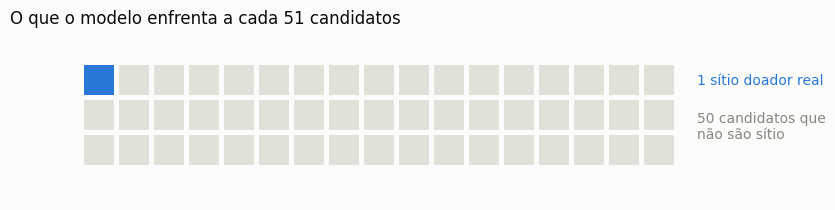

In [13]:
# Um retrato de 51 candidatos: a proporção que o modelo enfrenta.
n_quadrados = 51
colunas = 17
AZUL, NEUTRO = "#2a78d6", "#e1e0d9"

figura, eixo = plt.subplots(figsize=(9, 2.1), facecolor=SUPERFICIE)

for indice in range(n_quadrados):
    linha, coluna = divmod(indice, colunas)
    e_sitio = indice == 0
    eixo.add_patch(plt.Rectangle(
        (coluna, -linha), 0.86, 0.86,
        facecolor=AZUL if e_sitio else NEUTRO))

eixo.set_xlim(-0.3, colunas + 3.2)
eixo.set_ylim(-3.0, 1.2)
eixo.set_aspect("equal")
eixo.axis("off")
eixo.set_facecolor(SUPERFICIE)

eixo.text(colunas + 0.5, 0.43, "1 sítio doador real", va="center",
          fontsize=10, color=AZUL)
eixo.text(colunas + 0.5, -0.9, "50 candidatos que\nnão são sítio", va="center",
          fontsize=10, color=MUTED)

figura.suptitle("O que o modelo enfrenta a cada 51 candidatos",
                fontsize=12, color=TINTA, x=0.01, ha="left")
figura.tight_layout()
plt.show()

Repare que essa proporção vale para validação e teste, mas não para o treino.

O treino usa 10 negativos por positivo, e não 50. Subamostrar negativos deixa o treino mais barato sem mudar o que o modelo tem para aprender. Já a avaliação precisa da proporção real, senão o número que sai dela não descreve o uso.

In [14]:
for conjunto in ("train", "val", "test"):
    rotulos = dados[f"y_{conjunto}"]
    positivos = int(rotulos.sum())
    negativos = len(rotulos) - positivos
    print(f"{conjunto:>6}: {br(negativos / positivos):>3} negativos por positivo "
          f"({br(positivos / len(rotulos) * 100, 2):>5}% de positivos)")

 train:  10 negativos por positivo ( 9,09% de positivos)
   val:  50 negativos por positivo ( 1,96% de positivos)
  test:  50 negativos por positivo ( 1,96% de positivos)


## 3.2. Split por cromossomo

Falta decidir quais janelas vão para treino e quais para teste. Sortear ao acaso seria o caminho natural, e seria errado aqui.

O genoma do cupuaçu passou por expansões de famílias gênicas, e o próprio paper enfatiza isso: existem genes duplicados, com sequência quase idêntica, em locais diferentes. Um sorteio aleatório coloca cópias do mesmo gene nos dois lados, e o modelo acerta no teste por ter decorado no treino.

A divisão usada separa cromossomos inteiros.

In [15]:
for conjunto, cromossomos in meta["splits"].items():
    rotulos = dados[f"y_{conjunto}"]
    print(f"{conjunto:>6}: {', '.join(cromossomos):<40} "
          f"{br(len(rotulos)):>9} exemplos")

 train: chr1, chr2, chr3, chr4, chr5, chr6, chr7    55.001 exemplos
   val: chr8                                       101.995 exemplos
  test: chr9, chr10                                102.001 exemplos


Separar por cromossomo reduz o vazamento, mas não elimina: genes duplicados também existem entre cromossomos diferentes.

In [16]:
repetidas = meta["test_windows_seen_in_train"]
total_teste = len(dados["y_test"])

print(f"Janelas de teste idênticas a alguma do treino: "
      f"{repetidas} de {br(total_teste)} "
      f"({br(repetidas / total_teste * 100, 2)}%)")

Janelas de teste idênticas a alguma do treino: 66 de 102.001 (0,06%)


Esse número é um limite inferior do vazamento real. Ele conta apenas janelas byte a byte idênticas, e parálogos costumam ser parecidos, não idênticos. Serve como ordem de grandeza, e como lembrete de que dividir por cromossomo é uma mitigação, não uma garantia.

Um último ponto sobre a origem dos rótulos, que vale para qualquer trabalho com dado genômico anotado.

Os sítios usados aqui vêm de anotação computacional apoiada em evidência transcriptômica real, e não de validação experimental sítio a sítio. Estamos treinando um modelo para reproduzir a saída de outro modelo. O teto de desempenho possível é o teto do anotador.

Com o dado entendido e dividido, podemos criar o primeiro modelo.

# 4. Regressão logística <a id="regressao-logistica"></a>

O primeiro modelo da aula, e a baseline contra a qual todo o resto vai ser comparado.

O primeiro passo para escolher modelos para resolver uma tarefa é estabelecer uma baseline antes de partir para modelos caros. O motivo disso é que, num conjunto com 90% de uma classe e 10% da outra, responder sempre a classe majoritária já acerta 90%, e qualquer modelo que aprenda precisa superar isso para provar que serviu para alguma coisa. Sem uma baseline para bater, não dá para saber se houve progresso.

## 4.1. Achatamento do tensor

Um classificador linear não recebe matriz, recebe vetor. Então cada janela `(201, 4)` precisa virar uma lista de 804 números.

O que se perde nessa conta: cada par (posição, base) vira uma feature independente, e o modelo deixa de saber que a posição 40 é vizinha da 41.

Para um modelo linear isso não custa nada, porque ele já trataria as posições como independentes de qualquer forma.

In [17]:
X_treino_oh = one_hot_lote(dados["X_train"])
X_teste_oh = one_hot_lote(dados["X_test"])
y_treino = dados["y_train"]

# De (N, 201, 4) para (N, 804). O -1 deixa o numpy calcular a dimensão.
F_treino = X_treino_oh.reshape(len(X_treino_oh), -1)
F_teste = X_teste_oh.reshape(len(X_teste_oh), -1)

print("treino:", F_treino.shape)
print("teste: ", F_teste.shape)

treino: (55001, 804)
teste:  (102001, 804)


## 4.2. Ajuste do modelo

A regressão logística aprende um peso para cada uma das 804 features, mais um intercepto. Ela soma tudo e passa o resultado por uma sigmoide, o que devolve um número entre 0 e 1.

In [18]:
import time

from sklearn.linear_model import LogisticRegression

inicio = time.time()
modelo = LogisticRegression(max_iter=2000, n_jobs=-1)
modelo.fit(F_treino, y_treino)
segundos = time.time() - inicio

# Registro dos tempos de treino, para a comparação final da seção 5.
tempos = {"regressão logística": segundos}

print(f"Treinou em {br(segundos, 1)} s")
print(f"Parâmetros ajustados: {br(modelo.coef_.size + 1)}")

/home/hellsdeur/Code/courses/gendl/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


Treinou em 5,3 s
Parâmetros ajustados: 805


Com o treinamento finalizado, resta perguntar: treinou bem? Responder isso exige escolher uma métrica.

## 4.3. Acurácia, ou como mentir com números

Antes de medir o modelo, vale medir dois classificadores que não aprenderam nada.

O primeiro responde "não é sítio" para tudo, sem olhar para o DNA.

In [19]:
def acuracia(y_verdadeiro, y_predito):
    """Fração dos exemplos em que a predição bateu com o rótulo."""
    return (y_verdadeiro == y_predito).mean()


sempre_nao = np.zeros(len(y_teste), dtype=int)

print(f"Acurácia do 'sempre não': {br(acuracia(y_teste, sempre_nao) * 100, 2)}%")

Acurácia do 'sempre não': 98,04%


Perto de 98% de acurácia, sem olhar para o DNA e sem aprender nada.

Agora o classificador oposto, que aceita todo `GT` como sítio.

In [20]:
sempre_sim = np.ones(len(y_teste), dtype=int)

print(f"{'classificador':<18} {'acurácia':>9} {'sítios encontrados':>20}")
print("-" * 50)
for nome, predicao in [("sempre não", sempre_nao), ("todo GT é sítio", sempre_sim)]:
    encontrados = int(predicao[y_teste == 1].sum())
    print(f"{nome:<18} {br((predicao == y_teste).mean() * 100, 2):>8}% "
          f"{br(encontrados):>12} de {br(n_positivos)}")

classificador       acurácia   sítios encontrados
--------------------------------------------------
sempre não            98,04%            0 de 2.000
todo GT é sítio        1,96%        2.000 de 2.000


Os dois são inúteis, e de formas opostas: um nunca encontra nada, o outro aponta tudo.

A acurácia premia o primeiro com 98% e pune o segundo com 2%. Na prática é o primeiro que é mais perigoso, porque um modelo que nunca encontra nada passa despercebido num relatório.

Acurácia serviria para um problema balanceado e com grandes volumes de exemplos para cada classe, o que não é o caso aqui.

## 4.4. Precisão, revocação e PR-AUC

A acurácia mistura duas perguntas que precisam ficar separadas:

- precisão: dos `GT` que o modelo apontou como sítio, quantos eram mesmo?
- revocação: dos sítios reais que existem, quantos o modelo encontrou?

Nos dois classificadores triviais elas ficam em extremos opostos.

In [21]:
from sklearn.metrics import precision_score, recall_score

print(f"{'classificador':<18} {'precisão':>9} {'revocação':>10}")
print("-" * 40)
for nome, predicao in [("sempre não", sempre_nao), ("todo GT é sítio", sempre_sim)]:
    p = precision_score(y_teste, predicao, zero_division=0)
    r = recall_score(y_teste, predicao, zero_division=0)
    print(f"{nome:<18} {br(p * 100, 2):>8}% {br(r * 100, 2):>9}%")

classificador       precisão  revocação
----------------------------------------
sempre não             0,00%      0,00%
todo GT é sítio        1,96%    100,00%


Um modelo útil precisa das duas ao mesmo tempo, e há uma troca entre elas: para encontrar mais sítios é preciso aceitar mais candidatos, o que derruba a precisão.

O score da regressão logística permite percorrer essa troca. Cada limiar de corte dá um par (precisão, revocação), e o conjunto deles é a curva precisão-revocação. A área sob ela, PR-AUC, resume o modelo em um número.

In [22]:
from sklearn.metrics import average_precision_score, precision_recall_curve

score_logistica = modelo.decision_function(F_teste)
pr_auc = average_precision_score(y_teste, score_logistica)

print(f"PR-AUC da regressão logística: {br(pr_auc, 4)}")
print(f"Piso trivial (taxa de positivos): {br(taxa_positivos, 4)}")

PR-AUC da regressão logística: 0,6357
Piso trivial (taxa de positivos): 0,0196


## 4.5. ROC versus PR

A curva ROC é a métrica mais usada em classificação binária. Vale calcular as duas sobre exatamente as mesmas predições.

In [23]:
from sklearn.metrics import roc_auc_score, roc_curve

roc_auc = roc_auc_score(y_teste, score_logistica)

print(f"ROC-AUC: {br(roc_auc, 3)}   (piso 0,5)")
print(f"PR-AUC:  {br(pr_auc, 3)}   (piso {br(taxa_positivos, 4)})")

ROC-AUC: 0,969   (piso 0,5)
PR-AUC:  0,636   (piso 0,0196)


Um número parece dizer "problema resolvido". O outro diz "dois terços do caminho". As predições são as mesmas.

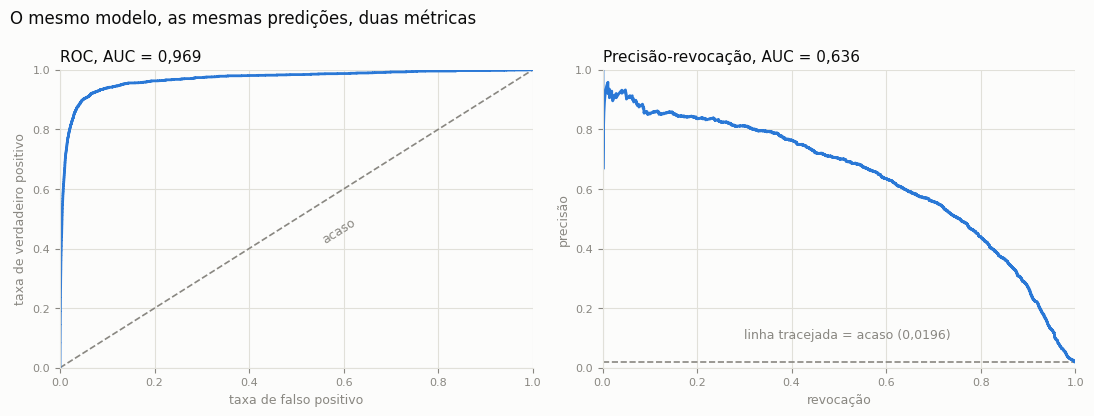

In [ ]:
fpr, tpr, _ = roc_curve(y_teste, score_logistica)
precisao_curva, revocacao_curva, _ = precision_recall_curve(y_teste, score_logistica)

AZUL, CINZA = "#2a78d6", "#898781"

figura, eixos = plt.subplots(1, 2, figsize=(11, 4.2), facecolor=SUPERFICIE)

# Painel ROC: a diagonal é o acaso.
eixos[0].plot([0, 1], [0, 1], linestyle="--", color=CINZA, linewidth=1.2)
eixos[0].plot(fpr, tpr, color=AZUL, linewidth=2)
eixos[0].set_title(f"ROC, AUC = {br(roc_auc, 3)}", fontsize=11, color=TINTA, loc="left")
eixos[0].set_xlabel("taxa de falso positivo", fontsize=9, color=MUTED)
eixos[0].set_ylabel("taxa de verdadeiro positivo", fontsize=9, color=MUTED)
eixos[0].text(0.55, 0.42, "acaso", fontsize=9, color=CINZA, rotation=32)

# Painel PR: o acaso é uma reta na altura da taxa de positivos.
eixos[1].axhline(taxa_positivos, linestyle="--", color=CINZA, linewidth=1.2)
eixos[1].plot(revocacao_curva, precisao_curva, color=AZUL, linewidth=2)
eixos[1].set_title(f"Precisão-revocação, AUC = {br(pr_auc, 3)}", fontsize=11, color=TINTA, loc="left")
eixos[1].set_xlabel("revocação", fontsize=9, color=MUTED)
eixos[1].set_ylabel("precisão", fontsize=9, color=MUTED)
eixos[1].text(0.30, 0.10, f"linha tracejada = acaso ({br(taxa_positivos, 4)})", fontsize=9, color=CINZA)

for eixo in eixos:
    eixo.set_xlim(0, 1)
    eixo.set_ylim(0, 1)
    eixo.set_facecolor(SUPERFICIE)
    eixo.grid(True, color=GRADE, linewidth=0.8)
    eixo.set_axisbelow(True)
    for lado in ("top", "right"):
        eixo.spines[lado].set_visible(False)
    for lado in ("bottom", "left"):
        eixo.spines[lado].set_color(GRADE)
    eixo.tick_params(colors=MUTED, labelsize=8)

figura.suptitle("O mesmo modelo, as mesmas predições, duas métricas", fontsize=12, color=TINTA, x=0.01, ha="left")
figura.tight_layout()
plt.show()

A causa está no denominador de cada métrica. A taxa de falso positivo, usada na curva ROC, divide os falsos positivos pelos 100.001 negativos do conjunto. Mil erros mal movem esse número. Já a precisão divide os mesmos mil erros pelo total de janelas apontadas, onde eles competem com apenas 2.000 positivos, e despenca.

Sempre que uma classe é rara, ROC-AUC é otimista. Daqui em diante, PR-AUC é a nossa métrica principal, e ROC-AUC aparece ao lado só para lembrar da diferença.

## 4.6. Coeficientes aprendidos

O modelo aprendeu 804 pesos. Remodelando de volta para `(201, 4)`, cada peso volta a aponta uma posição da janela e uma base.

Peso positivo significa que aquela base, naquela posição, empurra a decisão para "é sítio". Peso negativo empurra para o contrário.

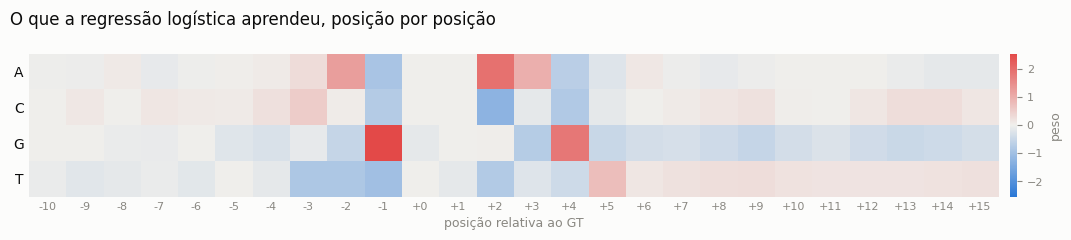

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

pesos = modelo.coef_[0].reshape(201, 4)

# Recorte da região informativa, para o heatmap caber na tela.
INICIO, FIM = POSICAO_DOADOR - 10, POSICAO_DOADOR + 16
recorte = pesos[INICIO:FIM]
posicoes = np.arange(INICIO, FIM) - POSICAO_DOADOR

# Escala divergente: azul para peso negativo, vermelho para positivo, cinza no
# zero. Os limites são simétricos para que o cinza caia exatamente em zero.
DIVERGENTE = LinearSegmentedColormap.from_list("peso", ["#2a78d6", "#f0efec", "#e34948"])
limite = np.abs(recorte).max()

figura, eixo = plt.subplots(figsize=(12, 2.4), facecolor=SUPERFICIE)
imagem = eixo.imshow(recorte.T, cmap=DIVERGENTE, vmin=-limite, vmax=limite, aspect="auto")

eixo.set_yticks(range(4))
eixo.set_yticklabels(list(BASES), fontsize=10, color=TINTA)
eixo.set_xticks(range(len(posicoes)))
eixo.set_xticklabels([f"{p:+d}" for p in posicoes], fontsize=8, color=MUTED)
eixo.set_xlabel("posição relativa ao GT", fontsize=9, color=MUTED)
eixo.tick_params(length=0)

for lado in eixo.spines.values():
    lado.set_visible(False)

barra = figura.colorbar(imagem, ax=eixo, pad=0.01)
barra.set_label("peso", fontsize=9, color=MUTED)
barra.ax.tick_params(colors=MUTED, labelsize=8)
barra.outline.set_visible(False)

figura.suptitle("O que a regressão logística aprendeu, posição por posição", fontsize=12, color=TINTA, x=0.01, ha="left")
figura.tight_layout()
plt.show()

O consenso `MAG|GTAAGT` reapareceu, com peso alto para `G` em −1, para `A` em −2, `A` em +2, `G` em +4 e `T` em +5. Agora o `MAG|GTAAGT` foi reconstruído por um modelo que nunca recebeu uma linha de biologia. Ele só otimizou para separar as duas classes.

A segunda é mais sutil. Olhe as posições 0 e +1, que são o próprio `GT`.

In [26]:
print("posição   peso de cada base")
for offset in (-1, 0, 1, 2):
    linha = pesos[POSICAO_DOADOR + offset]
    pesos_texto = "  ".join(f"{b}={br(w, 2):>5}" for b, w in zip(BASES, linha))
    print(f"  {offset:+3d}     {pesos_texto}")

posição   peso de cada base
   -1     A=-0,89  C=-0,76  G= 2,54  T=-1,00
   +0     A= 0,00  C= 0,00  G=-0,12  T= 0,00
   +1     A= 0,00  C= 0,00  G= 0,00  T=-0,12
   +2     A= 1,91  C=-1,26  G= 0,02  T=-0,79


Peso praticamente zero nas duas posições da âncora.

Faz sentido: toda janela do dataset tem `GT` ali, nos positivos e nos negativos. Uma feature que vale o mesmo nas duas classes não ajuda a separar nada, e o modelo corretamente a ignora.

É a confirmação, vinda de dentro do modelo, do que a seção 2 já dizia: achar `GT` é trivial, e toda a informação está no contexto ao redor.

## 4.7. Capacidade do modelo

O modelo tem 805 parâmetros. Vale perguntar quanto dado ele precisa para sustentá-los.

In [ ]:
sorteio = np.random.default_rng(42)
indices_pos = np.flatnonzero(y_treino == 1)
indices_neg = np.flatnonzero(y_treino == 0)

print(f"{'positivos':>10} {'exemplos':>10} {'por parâmetro':>14} {'PR-AUC':>9}")
print("-" * 48)
for n_pos in (250, 500, 1000, 2500, 5000):
    escolhidos = np.concatenate([
        sorteio.choice(indices_pos, n_pos, replace=False),
        sorteio.choice(indices_neg, n_pos * 10, replace=False)])
    pequeno = LogisticRegression(max_iter=2000, n_jobs=-1)
    pequeno.fit(F_treino[escolhidos], y_treino[escolhidos])
    p = average_precision_score(y_teste, pequeno.decision_function(F_teste))
    print(f"{br(n_pos):>10} {br(len(escolhidos)):>10} {br(len(escolhidos) / 805, 1):>14} {br(p, 4):>9}")

 positivos   exemplos  por parâmetro    PR-AUC
------------------------------------------------


/home/hellsdeur/Code/courses/gendl/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


       250      2.750            3,4    0,3743


/home/hellsdeur/Code/courses/gendl/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


       500      5.500            6,8    0,3994


...

     1.000     11.000           13,7    0,5268


/home/hellsdeur/Code/courses/gendl/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


     2.500     27.500           34,2    0,6112


/home/hellsdeur/Code/courses/gendl/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


     5.000     55.000           68,3    0,6362


A curva sobe e depois achata. Com 250 positivos o modelo tem cerca de três exemplos por parâmetro, e não consegue estimar 805 pesos com isso. Com 5.000 positivos são quase setenta exemplos por parâmetro, e o ganho já é pequeno.

Vale ressaltar que capacidade não é boa nem ruim por si só. Ela rende quando há dado que a sustente, e desperdiça quando não há.

# 5. Redes neurais convolucionais <a id="redes-convolucionais"></a>

A regressão logística trata cada posição da janela como independente. Ela não sabe que a posição 40 é vizinha da 41, e nada na estrutura dela diz isso.

Esta seção troca essa hipótese por outra, escolhida a partir de como o sinal biológico de fato se organiza.

## 5.1. Por que convolução em dados genômicos

A diferença entre a camada densa da seção 4 e uma camada convolucional é que a densa aprende padrões globais no espaço de entrada inteiro, a convolucional aprende padrões locais.

Duas propriedades do dado importantes para uma rede convolucional:

- **O sinal é local e curto**: sítio de splice, sítio de ligação de fator de transcrição, todos são padrões contíguos de poucas bases. Uma convolução com janela pequena embute essa vizinhança por construção, em vez de esperar que o modelo a descubra sozinho.

- **O mesmo padrão aparece em posições diferentes**: um filtro é um conjunto de pesos reaplicado em toda posição da sequência. O padrão é aprendido uma vez, e não uma vez por posição.

Para entender essa vantagem da convolucional em relação a linear, imagine que você pegue uma imagem e embaralhe os pixels. O resultado deixa de parecer uma imagem, e é por isso que a vizinhança entre pixels é conhecimento prévio que vale a pena embutir no modelo. Faça o mesmo com as janelas de DNA, permutando as 201 posições sempre da mesma forma em todos os exemplos. O sítio desaparece para qualquer leitor humano. A regressão logística, que trata cada par posição-base como uma feature independente.

Na prática o filtro é uma matriz pequena que percorre a janela, uma posição por vez, e em cada parada devolve um número.

<img src="https://cdn.jsdelivr.net/gh/hellsdeur/gendl/images/convolution.png" width="700">

A largura do filtro é o tamanho máximo do motivo que ele consegue reconhecer. Um filtro de largura 9 sobre DNA aprende motivos de até nove bases, e o consenso `AGGTAAGT` tem oito.

Além disso, saída não é um número, é uma sequência de números, um por posição. Para dados ordenados no tempo, como uma linha do tempo que mostra quando cada característica aparece na entrada. Aqui o eixo não é tempo, é posição na janela, mas a leitura continua valendo, e a saída da convolução diz onde cada filtro casou.

In [ ]:
from tensorflow import keras

# Quanto custa cada abordagem, em número de pesos.
conv = keras.Sequential([
    keras.layers.Input((201, 4)),
    keras.layers.Conv1D(32, 9, activation="relu")
    ])

print(f"regressão logística (804 features + intercepto): {br(805):>8} pesos")
print(f"camada convolucional, 32 filtros de largura 9:  {br(conv.count_params()):>8} pesos")
print()
print("A camada convolucional cobre as 201 posições com esses pesos,")
print("porque o mesmo filtro é reaplicado em cada uma delas.")

2026-09-15 11:14:33.318529: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-15 11:14:33.327159: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-15 11:14:33.612266: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-15 11:14:35.319819: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

regressão logística (804 features + intercepto):      805 pesos
camada convolucional, 32 filtros de largura 9:     1.184 pesos

A camada convolucional cobre as 201 posições com esses pesos,
porque o mesmo filtro é reaplicado em cada uma delas.


E0000 00:00:1789481675.818757   87770 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1789481675.844272   87770 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


A rede completa desta seção tem cerca de 50 mil parâmetros, contra 805 da logística. O argumento a favor da convolução é impor uma estrutura compatível com o dado, e isso faz a capacidade extra render em vez de desperdiçar.

## 5.2. Agregação do mapa de ativação

Passar 32 filtros sobre uma janela de 201 bases produz um mapa de ativação: para cada filtro, o quanto ele casou em cada posição.

In [ ]:
mapa = keras.Sequential([
    keras.layers.Input((201, 4)),
    keras.layers.Conv1D(32, 9, activation="relu")
    ])
print("saída da convolução:", mapa.output_shape)
print()
print("193 posições onde o filtro coube, vezes 32 filtros.")
print("Falta transformar isso em um único número por janela.")

saída da convolução: (None, 193, 32)

193 posições onde o filtro coube, vezes 32 filtros.
Falta transformar isso em um único número por janela.


Há duas formas de resumir esse mapa:

1. `GlobalMaxPooling`: para cada filtro, guardar o maior valor em qualquer posição. Responde se este padrão aparece em algum lugar da janela.
2. `MaxPooling` seguido de `Flatten`: reduzir a resolução mas manter a posição, e entregar tudo à camada densa. Responde se este padrão aparece, e onde.

Em resumo, o pooling preserva a informação de que o padrão está presente, e com que força, e descarta parte da informação de onde ele está.

Antes de treinar, decida qual das duas faz mais sentido aqui.

Uma dica: toda janela deste dataset, positiva ou negativa, tem `GT` na mesma posição 100.

Vale separar duas ideias que vêm juntas na mesma camada e são diferentes, porque a literatura tem nome para cada uma.

Compartilhar pesos entre posições dá à convolução uma propriedade chamada equivariância: se o padrão se desloca na entrada, a resposta se desloca junto na saída. A informação de posição continua inteira, apenas mudou de lugar. Isso é bom, e é o que torna a convolução eficiente, já que o filtro é o mesmo em qualquer parte da janela.

O pooling faz outra coisa. Ele troca equivariância por invariância: a saída passa a não mudar quando a entrada se desloca um pouco. Quanto mais agressivo o pooling, mais posição se perde, e o pooling global é o extremo, aquele em que nada de posição sobra.

<img src="https://cdn.jsdelivr.net/gh/hellsdeur/gendl/images/pool.png" width="760">

A convolução e o pooling são como uma priori infinitamente forte sobre os pesos: uma crença sobre o problema tão rígida que o modelo não consegue contrariá-la, por mais que os dados insistam. A convolução acredita que só a vizinhança importa. O pooling acredita que a posição exata não importa. Como toda priori, essas duas só ajudam quando a crença é verdadeira, e se a tarefa depende de preservar a posição precisa, aplicar pooling em tudo aumenta o erro.

## 5.3. Treino das duas variantes

As duas redes diferem em uma camada só. Todo o resto é igual.

A variante A usa `MaxPooling1D` seguido de `Flatten`, que reduz a resolução mas mantém a posição de cada casamento.

In [30]:
# Semente fixada antes de construir: os pesos iniciais são sorteados aqui,
# e não no treino.
keras.utils.set_random_seed(42)

modelo_maxpooling = keras.Sequential([
    keras.layers.Input((201, 4)),
    keras.layers.Conv1D(32, 9, activation="relu"),
    keras.layers.MaxPooling1D(4),
    keras.layers.Flatten(),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid"),
], name="maxpooling")

modelo_maxpooling.summary()

Model: "maxpooling"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 193, 32)        │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 48, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        49,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,401 (196.88 KB)

 Trainable params: 50,401 (196.88 KB)

 Non-trainable params: 0 (0.00 B)

A variante B troca `MaxPooling` mais `Flatten` por `GlobalMaxPooling`, e nada mais.

In [31]:
keras.utils.set_random_seed(42)

modelo_globalmaxpooling = keras.Sequential([
    keras.layers.Input((201, 4)),
    keras.layers.Conv1D(32, 9, activation="relu"),
    keras.layers.GlobalMaxPooling1D(),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid"),
], name="globalmaxpooling")

print(f"variante A, MaxPooling:       {br(modelo_maxpooling.count_params()):>7} parâmetros")
print(f"variante B, GlobalMaxPooling: {br(modelo_globalmaxpooling.count_params()):>7} parâmetros")

variante A, MaxPooling:        50.401 parâmetros
variante B, GlobalMaxPooling:   1.729 parâmetros


As duas redes já estão montadas, restando apenas treiná-las. Na chamada abaixo, `loss="binary_crossentropy"` é a função de perda usada em classificação de duas classes, e `optimizer="adam"` é o otimizador que ajusta os pesos a partir dela. O argumento `epochs` limita quantas passagens pelo conjunto de treino são permitidas.

In [ ]:
import time

# Um pedaço da validação basta para a parada antecipada, e deixa a época rápida.
X_val_oh = one_hot_lote(dados["X_val"][:20000])
y_val = dados["y_val"][:20000]


def treinar(modelo):
    """Treina monitorando PR-AUC de validação."""
    modelo.compile(optimizer="adam", loss="binary_crossentropy", metrics=[keras.metrics.AUC(curve="PR", name="pr")])
    inicio = time.time()
    historico = modelo.fit(
        X_treino_oh, y_treino,
        validation_data=(X_val_oh, y_val),
        epochs=30, batch_size=256, verbose=0,
        callbacks=[keras.callbacks.EarlyStopping(monitor="val_pr", mode="max", patience=5, restore_best_weights=True)])
    segundos = time.time() - inicio
    epocas = len(historico.history["loss"])
    tempos[modelo.name] = segundos
    print(f"{modelo.name:<18} {br(segundos, 0):>4} s, {epocas} épocas")
    return modelo.predict(X_teste_oh, verbose=0, batch_size=512).ravel()


score_maxpooling = treinar(modelo_maxpooling)
score_globalmaxpooling = treinar(modelo_globalmaxpooling)

maxpooling           31 s, 13 épocas
globalmaxpooling     23 s, 13 épocas


## 5.4. Resultados

In [ ]:
print(f"{'modelo':<26} {'PR-AUC':>8} {'ROC-AUC':>9}")
print("-" * 46)
print(f"{'piso trivial':<26} {br(taxa_positivos, 4):>8} {'-':>9}")
print(f"{'regressão logística':<26} {br(pr_auc, 4):>8} {br(roc_auc, 4):>9}")

results = [("CNN com MaxPooling", score_maxpooling), ("CNN com GlobalMaxPooling", score_globalmaxpooling)]

for nome, score in results:
    p = average_precision_score(y_teste, score)
    r = roc_auc_score(y_teste, score)
    print(f"{nome:<26} {br(p, 4):>8} {br(r, 4):>9}")

modelo                       PR-AUC   ROC-AUC
----------------------------------------------
piso trivial                 0,0196         -
regressão logística          0,6357    0,9693
CNN com MaxPooling           0,6997    0,9750
CNN com GlobalMaxPooling     0,0582    0,7393


A variante A ganha da regressão logística. A variante B perde por um fator de dez e fica logo acima do piso trivial. A diferença entre as duas é uma camada.

O mecanismo: o pooling global pergunta se o padrão aparece em algum lugar da janela. Mas positivos e negativos têm `GT` na mesma posição, e o que separa as classes é o contexto naquela posição específica. O pooling global descarta exatamente a informação que discrimina.

Vale notar que a variante B é **menor**, com 1.729 parâmetros contra 50.401. Ou seja, aqui o modelo mais enxuto é o pior. Ou seja, o que decide se uma arquitetura é boa não é o tamanho, é a hipótese que a arquitetura assume sobre o dado.

Um aviso sobre os números que apareceram na sua tela. Rede neural tem inicialização aleatória, e mesmo com semente fixa o resultado varia entre máquinas e entre CPU e GPU. Medimos essa variação na preparação da aula e a variante A oscila cerca de 0,02 de PR-AUC entre execuções, tipicamente entre 0,66 e 0,72.

A regressão logística não tem essa variação, porque não depende de sorteio. Compare os números da turma: a diferença entre eles é pequena, e a diferença para a variante B não é.

Antes de sair daqui com a conclusão de que `GlobalMaxPooling` é uma camada ruim, vale ver a mesma camada funcionando bem.

Este é um convnet 1D para classificar resenhas de filme como positivas ou negativas:

```python
model = Sequential()
model.add(layers.Embedding(max_features, 128, input_length=max_len))
model.add(layers.Conv1D(32, 7, activation='relu'))
model.add(layers.MaxPooling1D(5))
model.add(layers.Conv1D(32, 7, activation='relu'))
model.add(layers.GlobalMaxPooling1D())
model.add(layers.Dense(1))
```

A penúltima linha é a camada que acabou de fracassar aqui, e no problema dele ela vai bem, com desempenho próximo ao de uma LSTM e a uma fração do custo.

A diferença está no dado. Numa resenha, a palavra que decide o sentimento pode aparecer na primeira linha ou na última, e perguntar apenas se ela aparece em algum lugar é a pergunta certa. Na nossa janela o candidato está sempre na mesma posição, e a pergunta certa é o que existe em volta dele.

## 5.5. ROC versus PR da CNN

Aqui as variantes discordam bastante.

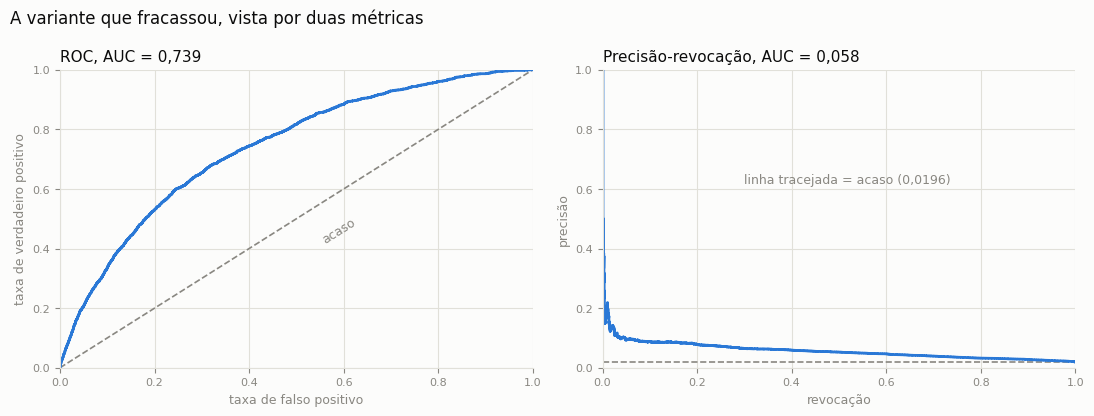

In [ ]:
pr_b = average_precision_score(y_teste, score_globalmaxpooling)
roc_b = roc_auc_score(y_teste, score_globalmaxpooling)

fpr_b, tpr_b, _ = roc_curve(y_teste, score_globalmaxpooling)
prec_b, rev_b, _ = precision_recall_curve(y_teste, score_globalmaxpooling)

figura, eixos = plt.subplots(1, 2, figsize=(11, 4.2), facecolor=SUPERFICIE)

eixos[0].plot([0, 1], [0, 1], linestyle="--", color=CINZA, linewidth=1.2)
eixos[0].plot(fpr_b, tpr_b, color=AZUL, linewidth=2)
eixos[0].set_title(f"ROC, AUC = {br(roc_b, 3)}", fontsize=11, color=TINTA, loc="left")
eixos[0].set_xlabel("taxa de falso positivo", fontsize=9, color=MUTED)
eixos[0].set_ylabel("taxa de verdadeiro positivo", fontsize=9, color=MUTED)
eixos[0].text(0.55, 0.42, "acaso", fontsize=9, color=CINZA, rotation=32)

eixos[1].axhline(taxa_positivos, linestyle="--", color=CINZA, linewidth=1.2)
eixos[1].plot(rev_b, prec_b, color=AZUL, linewidth=2)
eixos[1].set_title(f"Precisão-revocação, AUC = {br(pr_b, 3)}", fontsize=11, color=TINTA, loc="left")
eixos[1].set_xlabel("revocação", fontsize=9, color=MUTED)
eixos[1].set_ylabel("precisão", fontsize=9, color=MUTED)
eixos[1].text(0.30, 0.62, f"linha tracejada = acaso ({br(taxa_positivos, 4)})", fontsize=9, color=CINZA)

for eixo in eixos:
    eixo.set_xlim(0, 1)
    eixo.set_ylim(0, 1)
    eixo.set_facecolor(SUPERFICIE)
    eixo.grid(True, color=GRADE, linewidth=0.8)
    eixo.set_axisbelow(True)
    for lado in ("top", "right"):
        eixo.spines[lado].set_visible(False)
    for lado in ("bottom", "left"):
        eixo.spines[lado].set_color(GRADE)
    eixo.tick_params(colors=MUTED, labelsize=8)

figura.tight_layout()
plt.show()

Um modelo quase inútil, que a curva ROC ainda faz parecer razoável.

A PR-AUC está praticamente encostada no piso, e a ROC-AUC continua num valor que, num relatório, passaria sem ninguém perguntar nada.

## 5.6. Filtros aprendidos

Cada um dos 32 filtros da variante A é uma matriz `(9, 4)`: nove posições, quatro bases. Abaixo, os seis de maior magnitude.

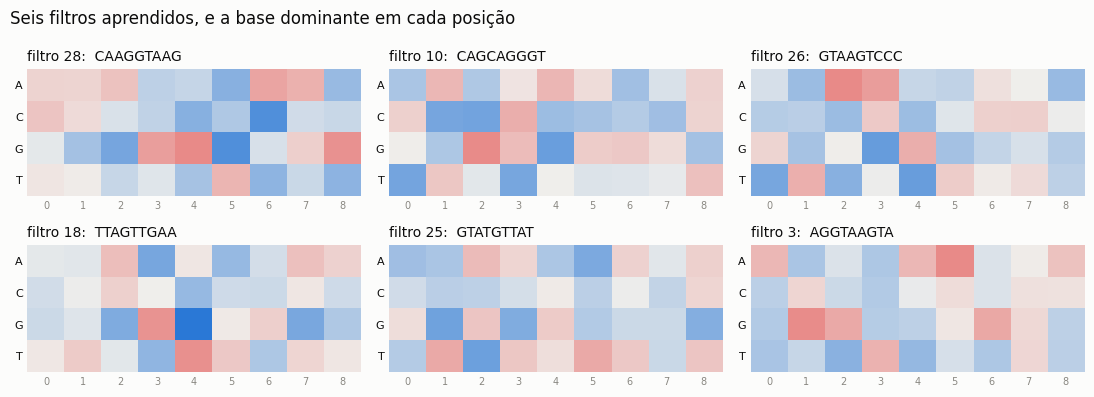

In [ ]:
filtros = modelo_maxpooling.layers[0].get_weights()[0]   # (9, 4, 32)
normas = np.linalg.norm(filtros.reshape(-1, filtros.shape[-1]), axis=0)
escolhidos = np.argsort(-normas)[:6]

figura, eixos = plt.subplots(2, 3, figsize=(11, 4.0), facecolor=SUPERFICIE)
limite = np.abs(filtros[:, :, escolhidos]).max()

for eixo, k in zip(eixos.ravel(), escolhidos):
    filtro = filtros[:, :, k]
    eixo.imshow(filtro.T, cmap=DIVERGENTE, vmin=-limite, vmax=limite, aspect="auto")
    # Base de maior peso em cada uma das 9 posições do filtro.
    dominante = "".join(BASES[int(np.argmax(filtro[p]))] for p in range(9))
    eixo.set_title(f"filtro {k}:  {dominante}", fontsize=10, color=TINTA, loc="left")
    eixo.set_yticks(range(4))
    eixo.set_yticklabels(list(BASES), fontsize=8, color=TINTA)
    eixo.set_xticks(range(9))
    eixo.set_xticklabels(range(9), fontsize=7, color=MUTED)
    eixo.tick_params(length=0)
    for lado in eixo.spines.values():
        lado.set_visible(False)

figura.tight_layout()
plt.show()

Vários deles carregam pedaços do consenso. É comum aparecer `GTAAGT` inteiro, ou `AGGTAAGT` com o `AG` do lado do éxon incluído. Alguns vão parecer ruído, outros capturam combinações que não têm nome na literatura.

# 6. Redes neurais recorrentes <a id="redes-recorrentes"></a>

Nem a regressão logística nem a convolução tem memória. Cada janela entra inteira, é processada de uma vez, e nada é guardado de uma posição para a seguinte. Esta seção testa um modelo que lê a janela inteira, base por base, em ordem, mantendo memória do que já viu.

## 6.1. Dependência de longo alcance

A promessa da rede recorrente é captar relação entre partes distantes da sequência. A posição 10 e a posição 190 nunca entram juntas num filtro de largura 9, mas entram na memória de uma recorrente que percorreu as duas.

E a promessa é razoável, porque splicing é um processo de longo alcance na biologia. O spliceossomo reconhece o par doador-aceitador, e esses dois podem estar separados por milhares de bases.

Assim, se existir dependência de longo alcance dentro desta janela, a recorrente deve ganhar da convolução.

## 6.2. Arquitetura e treino

Antes de montar a rede, vale abrir o que uma camada recorrente faz por dentro. De maneira direta, uma recorrente é um laço `for` que reaproveita o resultado da iteração anterior. A cada posição da sequência ela combina duas coisas, a base que está lendo agora e um vetor de estado que resume tudo o que já leu, e produz um estado novo que entra na volta seguinte.

<img src="https://cdn.jsdelivr.net/gh/hellsdeur/gendl/images/rnn.png" width="820">

Os pesos são os mesmos em todas as posições, exatamente como o filtro da convolução era o mesmo em todas as posições. A célula abaixo escreve esse laço em numpy e o roda sobre uma janela real do nosso conjunto de treino.

In [36]:
# O laço que define uma camada recorrente, adaptado de Chollet, 2a ed.,
# cap. 10.3. Pesos sorteados e nenhum treino: o objetivo aqui é ver o
# formato do cálculo, não obter uma predição.
rng = np.random.default_rng(42)

janela = X_treino_oh[0]        # uma janela de verdade do conjunto de treino
tamanho_estado = 8

W = rng.normal(size=(tamanho_estado, 4)) * 0.3               # pesos da entrada
U = rng.normal(size=(tamanho_estado, tamanho_estado)) * 0.3  # pesos do estado
b = np.zeros(tamanho_estado)

estado = np.zeros(tamanho_estado)
for base in janela:            # percorre as 201 posições, uma de cada vez
    estado = np.tanh(W @ base + U @ estado + b)

print("Entrada:", janela.shape, " 201 posições, cada uma com 4 números")
print("Saída:  ", estado.shape, "   um vetor só, o resumo da janela inteira")
print()
print("Estado final:", np.round(estado, 3))

Entrada: (201, 4)  201 posições, cada uma com 4 números
Saída:   (8,)    um vetor só, o resumo da janela inteira

Estado final: [-0.139 -0.428 -0.377 -0.049 -0.411 -0.386 -0.076 -0.079]


Duzentas e uma posições entraram, e saiu um vetor de oito números. É esse resumo que a camada densa recebe, e é nele que precisa caber tudo o que a janela tinha de informativo.

O laço acima é uma recorrente simples, e ela tem um defeito conhecido. Ao chegar na posição 200, o que entrou na posição 10 já passou por cento e noventa multiplicações e praticamente não sobrou. Dependência longa é justamente o que a arquitetura promete capturar, e é o que ela perde. A LSTM foi desenhada para resolver isso ao acrescentar, ao lado do estado, um segundo canal que atravessa a sequência sofrendo menos interferência, mais algumas operações que decidem o que entra nesse canal, o que sai e o que é descartado.

```
output_t = activation(dot(state_t, Uo) + dot(input_t, Wo) + dot(c_t, Vo) + bo)

i_t = activation(dot(state_t, Ui) + dot(input_t, Wi) + bi)
f_t = activation(dot(state_t, Uf) + dot(input_t, Wf) + bf)
k_t = activation(dot(state_t, Uk) + dot(input_t, Wk) + bk)

c_t+1 = i_t * k_t + c_t * f_t
```

A arquitetura é pequena de propósito, para o custo vir da recorrência e não do tamanho.

Bidirecional porque não há razão para privilegiar um sentido de leitura: a janela tem éxon de um lado e íntron do outro, e os dois lados informam. Uma camada bidirecional é exatamente isso, duas recorrentes independentes, uma lendo do começo para o fim e outra do fim para o começo, com as saídas concatenadas no final.

<img src="https://cdn.jsdelivr.net/gh/hellsdeur/gendl/images/birnn.png" width="700">

A bidirecional serve quando a ordem importa mas o sentido em que você lê não importa. Em série temporal o sentido importa, porque o passado recente prediz melhor que o distante, e ali a bidirecional piora o resultado. Em texto e em sequência biológica não existe esse privilégio. Por esse motivo, bioinformática está entre as áreas em que recorrentes bidirecionais mais deram certo.

In [37]:
keras.utils.set_random_seed(42)

modelo_lstm = keras.Sequential([
    keras.layers.Input((201, 4)),
    keras.layers.Bidirectional(keras.layers.LSTM(32)),
    keras.layers.Dense(1, activation="sigmoid"),
], name="lstm")

modelo_lstm.summary()

print(f"\nSão {br(modelo_lstm.count_params())} parâmetros, bem menos que os "
      f"{br(modelo_maxpooling.count_params())} da CNN da seção 4.")

Model: "lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 64)             │         9,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,537 (37.25 KB)

 Trainable params: 9,537 (37.25 KB)

 Non-trainable params: 0 (0.00 B)


São 9.537 parâmetros, bem menos que os 50.401 da CNN da seção 4.


Agora o treino.

Repare no orçamento: 60 épocas contra as 30 que a CNN teve, e paciência maior na parada antecipada. A recorrente converge mais devagar, e com 30 épocas ela ainda estava melhorando quando o treino parava. Comparar um modelo interrompido no meio com outro que convergiu diria só sobre quem ganhou mais tempo. O orçamento maior é o que torna a comparação honesta.

In [38]:
inicio = time.time()

modelo_lstm.compile(optimizer="adam", loss="binary_crossentropy",
                    metrics=[keras.metrics.AUC(curve="PR", name="pr")])
historico_lstm = modelo_lstm.fit(
    X_treino_oh, y_treino,
    validation_data=(X_val_oh, y_val),
    epochs=60, batch_size=256, verbose=2,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor="val_pr", mode="max", patience=8, restore_best_weights=True)])

tempos["lstm"] = time.time() - inicio
score_lstm = modelo_lstm.predict(X_teste_oh, verbose=0, batch_size=512).ravel()

print(f"\nTreinou em {br(tempos['lstm'], 0)} s, "
      f"{len(historico_lstm.history['loss'])} épocas")

Epoch 1/60
215/215 - 26s - 121ms/step - loss: 0.3267 - pr: 0.0955 - val_loss: 0.1314 - val_pr: 0.0425
Epoch 2/60
215/215 - 23s - 106ms/step - loss: 0.2919 - pr: 0.1708 - val_loss: 0.1409 - val_pr: 0.0244
Epoch 3/60
215/215 - 22s - 101ms/step - loss: 0.2973 - pr: 0.1251 - val_loss: 0.1362 - val_pr: 0.0339
Epoch 4/60
215/215 - 22s - 104ms/step - loss: 0.2899 - pr: 0.1569 - val_loss: 0.1448 - val_pr: 0.0316
Epoch 5/60
215/215 - 22s - 103ms/step - loss: 0.2589 - pr: 0.2689 - val_loss: 0.1184 - val_pr: 0.0970
Epoch 6/60
215/215 - 21s - 96ms/step - loss: 0.2385 - pr: 0.3303 - val_loss: 0.1319 - val_pr: 0.1165
Epoch 7/60
215/215 - 19s - 87ms/step - loss: 0.2330 - pr: 0.3563 - val_loss: 0.1172 - val_pr: 0.1231
Epoch 8/60
215/215 - 19s - 87ms/step - loss: 0.2335 - pr: 0.3618 - val_loss: 0.1234 - val_pr: 0.1183
Epoch 9/60
215/215 - 19s - 87ms/step - loss: 0.2293 - pr: 0.3819 - val_loss: 0.1176 - val_pr: 0.1408
Epoch 10/60
215/215 - 19s - 88ms/step - loss: 0.2277 - pr: 0.3829 - val_loss: 0.1135 -

## 6.3. Custo computacional da recorrência

A lentidão da LSTM é consequência da arquitetura. Numa convolução, as 201 posições são processadas ao mesmo tempo. Cada uma só depende das nove bases embaixo do filtro, e nada impede que todas sejam calculadas de uma vez. Numa recorrente, a posição 101 precisa do estado que saiu da posição 100, que precisou da 99, e assim por diante. São 201 passos que só podem acontecer em sequência.

Duas consequências práticas:

1. o custo por época cresce com o comprimento da janela, e não cai dividindo o trabalho entre mais núcleos;
2. GPU ajuda menos aqui do que numa convolução, porque o gargalo é a dependência entre passos, não a quantidade de contas.

É por isso que a mesma janela de 201 bases custa segundos numa CNN e minutos numa recorrente.

Vale nomear o que as duas arquiteturas têm em comum, porque é o mesmo truque aplicado a eixos diferentes. A convolução reaplica o mesmo filtro em toda posição e assume, ao fazer isso, que um motivo significa a mesma coisa onde quer que apareça. A recorrente reaplica os mesmos pesos em todo passo e assume que a relação entre uma posição e a seguinte é a mesma do começo ao fim da sequência. Isso está ligado ao conceito de regularização ciente do domínio, em vez de esperar que a rede descubra sozinha uma regularidade que já conhecemos, ela é escrita na estrutura e o número de parâmetros cai junto.

## 6.4. Resultados

In [39]:
modelos = [
    ("regressão logística", modelo.decision_function(F_teste), "regressão logística"),
    ("CNN com MaxPooling", score_maxpooling, "maxpooling"),
    ("CNN com GlobalMaxPooling", score_globalmaxpooling, "globalmaxpooling"),
    ("LSTM bidirecional", score_lstm, "lstm"),
]

print(f"{'modelo':<26} {'PR-AUC':>8} {'ROC-AUC':>9} {'treino':>10}")
print("-" * 57)
print(f"{'piso trivial':<26} {br(taxa_positivos, 4):>8} {'-':>9} {'-':>10}")
for nome, score, chave in modelos:
    p = average_precision_score(y_teste, score)
    r = roc_auc_score(y_teste, score)
    print(f"{nome:<26} {br(p, 4):>8} {br(r, 4):>9} "
          f"{br(tempos[chave], 0):>7} s")

modelo                       PR-AUC   ROC-AUC     treino
---------------------------------------------------------
piso trivial                 0,0196         -          -
regressão logística          0,6357    0,9693       5 s
CNN com MaxPooling           0,6997    0,9750      31 s
CNN com GlobalMaxPooling     0,0582    0,7393      23 s
LSTM bidirecional            0,6396    0,9666   1.161 s


A LSTM perde para a CNN, e por uma margem clara.

Contra a regressão logística ela fica praticamente empatada. A diferença entre as duas é menor que a variação que a própria CNN apresenta entre execuções, ou seja, não dá para afirmar que uma é melhor que a outra.

O que não é ambíguo é o preço. Compare a última coluna: a recorrente custou dezenas de vezes mais tempo que os dois modelos com os quais empata ou perde.

E há um detalhe que precisa ser dito, porque muda a leitura: ela **não convergiu**. Bateu o teto de 60 épocas ainda melhorando.

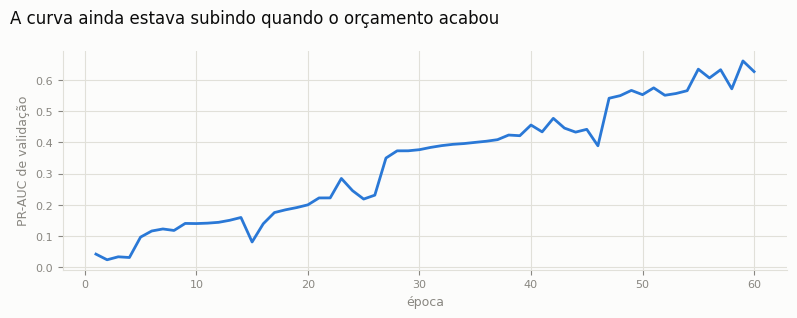

In [ ]:
val_pr = historico_lstm.history["val_pr"]

figura, eixo = plt.subplots(figsize=(8, 3.2), facecolor=SUPERFICIE)
eixo.plot(range(1, len(val_pr) + 1), val_pr, color=AZUL, linewidth=2)
eixo.set_xlabel("época", fontsize=9, color=MUTED)
eixo.set_ylabel("PR-AUC de validação", fontsize=9, color=MUTED)
eixo.set_facecolor(SUPERFICIE)
eixo.grid(True, color=GRADE, linewidth=0.8)
eixo.set_axisbelow(True)
for lado in ("top", "right"):
    eixo.spines[lado].set_visible(False)
for lado in ("bottom", "left"):
    eixo.spines[lado].set_color(GRADE)
eixo.tick_params(colors=MUTED, labelsize=8)

figura.tight_layout()
plt.show()

A curva não achata. Com mais épocas ela provavelmente continuaria subindo, e é possível que em algum ponto alcançasse a CNN. Não sabemos onde ela para e descobrir custaria mais tempo do que a resposta vale, pelo menos para a aula de hoje.

Vale registrar o contraste de orçamento:

| modelo | épocas até parar | parou por quê |
|---|---|---|
| CNN com MaxPooling | ~12 | convergiu, a validação parou de melhorar |
| LSTM bidirecional | 60 | acabou o orçamento, ainda melhorando |

## 6.5. Navalha de Occam

Voltando à hipótese do começo da seção: se existir dependência de longo alcance **dentro desta janela**, a recorrente deve ganhar.

Ela não ganhou, e o motivo é que a hipótese não se aplica ao recorte. Dentro de 201 bases centradas no doador, o que existe é o motivo local mais um viés de composição distribuído, e a convolução pega os dois melhor e mais barato.

A dependência de longo alcance de verdade no splicing é entre doador e aceitador, separados por milhares de bases. Essa dependência **foi recortada fora** quando escolhemos a janela de 201 nt. Nenhum modelo captura o que o dado não contém.

In [41]:
mediana_intron = 167   # medido no genoma do cupuaçu, na preparação da aula

print(f"Janela usada nesta aula:          {201:>7} bases")
print(f"Íntron mediano deste genoma:      {mediana_intron:>7} bases")
print(f"Íntron mais longo deste genoma:   {147316:>7} bases")
print()
print("O aceitador do íntron mediano já cai fora da janela.")
print("A dependência que a recorrente procuraria não está no dado.")

Janela usada nesta aula:              201 bases
Íntron mediano deste genoma:          167 bases
Íntron mais longo deste genoma:    147316 bases

O aceitador do íntron mediano já cai fora da janela.
A dependência que a recorrente procuraria não está no dado.


Mas se a LSTM tem muito mais capacidade que a regressão logística, então ela não deveria pelo menos empatar sempre? Não necessariamente, pois a solução simples pode estar dentro do espaço de hipóteses do modelo, e ainda assim o treino não a encontra, e é por isso que montar a estrutura certa na arquitetura rende mais do que aumentar a capacidade e torcer.

A navalha de Occam, em formato operacional: entre duas explicações que dão o mesmo resultado, prefira a mais simples.

Aqui o caso é mais concreto que o ditado. A recorrente levou dezenas de vezes mais tempo para empatar com um modelo de 805 parâmetros que roda em três segundos, e para perder de um que roda em dezessete.

Isso não significa que recorrente é ruim, nem que a regra é usar sempre CNN. Duas coisas mais específicas:

1. A arquitetura codifica uma hipótese sobre a estrutura do dado, e a hipótese da recorrência não se paga neste recorte. Quando a ordem global carrega informação, uma recorrente é a escolha certa, mas quando não carrega, uma convolução 1D funciona pelo menos igual e custa muito menos;
2. Custo faz parte da avaliação. Um modelo que talvez chegasse lá depois de uma hora não é comparável a um que chega em dezessete segundos.

Mudando o recorte, com janela de dezenas de milhares de bases contendo doador e aceitador juntos, e a conclusão pode mudar junto.

# 7. PyTorch e modelos do estado da arte <a id="pytorch-estado-arte"></a>

Aqui vamos mostrar como as arquiteturas neurais geralmente são apresentadas em artigos científicos, não em Keras mas em PyTorch. Além disso, vamos olhar um modelo de fronteira e reconhecer alguns dos conceitos vistos na aula.

## 7.1. A mesma arquitetura em PyTorch

Keras e PyTorch são as duas bibliotecas mais usadas para redes neurais. Para pesquisa, a vantagem do PyTorch está em usar um grafo computacional dinâmico (eager execution), o que dá mais liberdade para customizar o loop de treinamento, manipular gradientes, depurar passo a passo com ferramentas Python padrão, e implementar arquiteturas não convencionais.

Abaixo, a mesma CNN da seção 5 escrita em PyTorch. Ela não vai ser treinada, só montada, para a comparação ficar concreta.

In [42]:
import torch
from torch import nn

cnn_pytorch = nn.Sequential(
    nn.Conv1d(4, 32, 9), nn.ReLU(),
    nn.MaxPool1d(4),
    nn.Flatten(),
    nn.Linear(48 * 32, 32), nn.ReLU(),
    nn.Linear(32, 1), nn.Sigmoid(),
)

print(cnn_pytorch)

Sequential(
  (0): Conv1d(4, 32, kernel_size=(9,), stride=(1,))
  (1): ReLU()
  (2): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  (3): Flatten(start_dim=1, end_dim=-1)
  (4): Linear(in_features=1536, out_features=32, bias=True)
  (5): ReLU()
  (6): Linear(in_features=32, out_features=1, bias=True)
  (7): Sigmoid()
)


Camada por camada, a correspondência é direta:

| Keras | PyTorch |
|---|---|
| `keras.layers.Conv1D(32, 9)` | `nn.Conv1d(4, 32, 9)` |
| `keras.layers.MaxPooling1D(4)` | `nn.MaxPool1d(4)` |
| `keras.layers.Flatten()` | `nn.Flatten()` |
| `keras.layers.Dense(32)` | `nn.Linear(1536, 32)` |
| `keras.layers.Dense(1)` | `nn.Linear(32, 1)` |

Duas diferenças que aparecem já na primeira hora de quem troca de biblioteca:

1. PyTorch pede o tamanho de entrada de cada camada, Keras deduz sozinho. Por isso aparece `4` no `Conv1d` e `1536` no primeiro `Linear`.
2. A ordem dos eixos é trocada. Keras espera `(exemplos, comprimento, canais)`, PyTorch espera `(exemplos, canais, comprimento)`.

In [43]:
entrada_keras = X_teste_oh[:2].shape
entrada_torch = tuple(torch.zeros(2, 4, 201).shape)

print(f"Keras espera:   {entrada_keras}   (exemplos, comprimento, canais)")
print(f"PyTorch espera: {entrada_torch}   (exemplos, canais, comprimento)")
print()
print("Trocar de biblioteca sem trocar a ordem dos eixos é o erro mais comum")
print("de quem faz a migração, e o mais chato de achar.")

Keras espera:   (2, 201, 4)   (exemplos, comprimento, canais)
PyTorch espera: (2, 4, 201)   (exemplos, canais, comprimento)

Trocar de biblioteca sem trocar a ordem dos eixos é o erro mais comum
de quem faz a migração, e o mais chato de achar.


E a prova de que é de fato a mesma arquitetura: as duas têm exatamente o mesmo número de pesos a ajustar.

In [ ]:
params_keras = modelo_maxpooling.count_params()
params_torch = sum(p.numel() for p in cnn_pytorch.parameters())

print(f"Keras:   {br(params_keras):>8} parâmetros")
print(f"PyTorch: {br(params_torch):>8} parâmetros")

Keras:     50.401 parâmetros
PyTorch:   50.401 parâmetros

Iguais.


O que falta no código acima é o laço de treino, que em PyTorch é escrito à mão: percorrer os lotes, calcular a perda, chamar o backward, atualizar os pesos. O Keras esconde tudo isso dentro do `.fit()`.

Nenhum dos dois é mais correto. Um é mais explícito, o outro é mais curto.

## 7.2. AlphaGenome

O AlphaGenome ([Avsec et al., *Nature* 649:1206-1218, 2026](https://www.nature.com/articles/s41586-025-10014-0)) é um dos modelos de fronteira para predição de função a partir de sequência genômica. Vale olhar duas figuras do artigo: a arquitetura e o desempenho.

<img src="https://cdn.jsdelivr.net/gh/hellsdeur/gendl/images/alphagenome-a.png" width="820">

Percorrendo o diagrama, boa parte do que aparece já é conhecida:

| no diagrama | onde apareceu nesta aula |
|---|---|
| entrada de sequência de DNA | seção 2 |
| a resolução cai e depois volta a subir | o pooling da seção 5 |
| várias cabeças de saída, uma por tipo de sinal | seções 4 a 6 |
| `Splice sites`, uma das onze saídas | é o problema inteiro desta aula |

O conteúdo da aula até aqui é uma linha entre onze, com 4 trilhas em humano e 4 em camundongo, ao lado de expressão, acessibilidade de cromatina e contato entre regiões distantes do DNA.

O que é novo: os blocos de atenção, a janela de entrada de 1 Mb, o processamento repartido entre vários dispositivos, e o fato de haver muitas saídas ao mesmo tempo em vez de uma só. As camadas convolucionais estão lá, mas escondidas dentro das caixas `Encoders` e `Decoders`.

A segunda figura é a tabela de desempenho.

<img src="https://cdn.jsdelivr.net/gh/hellsdeur/gendl/images/alphagenome-d.png" width="900">

Na primeira linha a tarefa é `Splice site classification`, que é a desta aula, e a métrica é `auPRC`, que é a PR-AUC. A mesma que a seção 4 escolheu, pelo mesmo motivo: sítios são raros, e uma métrica que ignora isso mente.

Repare também que a métrica muda conforme a pergunta. Onde a saída é uma classe, aparece `auPRC`. Onde é um valor contínuo ao longo do genoma, aparece correlação de Pearson. Onde é o formato de um perfil, aparece uma medida de divergência.

Sobre o ganho sobre o melhor modelo concorrente de cada tarefa (coluna da direita):

1. **o ganho em splicing é o menor da figura, 1,0%.** Existe um modelo especializado em splicing, o DeltaSplice, e ele já vai muito bem. O AlphaGenome mal o supera nessa tarefa específica;
2. **em outras tarefas o ganho é grande**, chegando a 28,2% em cobertura de RNA-seq e 42,3% em mapas de contato. O valor do modelo está na amplitude, em fazer onze coisas razoavelmente bem, e não em vencer cada especialista no terreno dele;
3. **há um número negativo na figura**, de -0,3% contra o Enformer.

Vale ressaltar que para a classificação de sítios de splice, apesar do AlphaGenome marcar 0,79 e o modelo da seção 5 marcar 0,70 na mesma métrica, não há comparação entre eles. São espécies diferentes, dados diferentes, e formulações diferentes, porque eles avaliam posição a posição ao longo do genoma, enquanto para o cupuaçu foram classificadas janelas recortadas.

In [45]:
linhas = [
    ("janela de entrada", "201 bases", "~1 milhão de bases"),
    ("saídas do modelo", "1 (é sítio?)", "milhares"),
    ("sítios cobertos", "doador", "doador e aceitador"),
    ("outros sinais", "nenhum", "expressão, e mais"),
    ("treino da CNN", br(tempos["maxpooling"], 0) + " s", "escala industrial"),
]

print(f"{'':<20} {'esta aula':>14}   {'AlphaGenome':<20}")
print("-" * 58)
for rotulo, aqui, la in linhas:
    print(f"{rotulo:<20} {aqui:>14}   {la:<20}")

                          esta aula   AlphaGenome         
----------------------------------------------------------
janela de entrada         201 bases   ~1 milhão de bases  
saídas do modelo       1 (é sítio?)   milhares            
sítios cobertos              doador   doador e aceitador  
outros sinais                nenhum   expressão, e mais   
treino da CNN                  31 s   escala industrial   


A diferença é de escala e de recursos, não de conceito. Os blocos são os mesmos, e é por isso que dá para olhar a figura de um artigo da *Nature* e reconhecer o que está acontecendo.

## 7.3. Limites do recorte adotado

Terminar pelos limites é mais útil do que terminar por uma conclusão redonda. Três deles, e todos importam para quem for usar isso na própria pesquisa.

**O primeiro é um teto de revocação embutido no dataset.** Todo candidato aqui é um `GT`, então íntrons que começam com `GC` ou `AT` estão fora por construção. Nenhum modelo desta aula pode encontrá-los, por melhor que seja.

In [46]:
canonicos = genoma["donor_sites"]
anotados = genoma["annotated_introns"]

print(f"Íntrons anotados no genoma:        {br(anotados):>9}")
print(f"Começam com GT, os únicos vistos:  {br(canonicos):>9}")
print(f"Teto de revocação desta aula:      {br(canonicos / anotados * 100, 2):>8}%")

Íntrons anotados no genoma:          119.378
Começam com GT, os únicos vistos:    117.569
Teto de revocação desta aula:         98,48%


**O segundo é a origem dos rótulos.** Eles vêm de anotação computacional apoiada em evidência transcriptômica, e não de validação experimental sítio a sítio. O teto real de desempenho é o teto do anotador, e nenhuma métrica desta aula enxerga esse limite.

**O terceiro é a formulação do problema.** SpliceAI e AlphaGenome não classificam janelas isoladas. Eles percorrem o cromossomo prevendo, para cada posição, se ali existe um sítio. É a formulação correta, e não cabia no
orçamento de uma aula.

Esse terceiro ponto fecha o laço com a seção 6. A dependência de longo alcance que a LSTM não encontrou é justamente a que só existe quando a janela é grande o bastante para conter doador e aceitador juntos. O problema não estava na arquitetura, estava no recorte.

## Referências

Artigos científicos:

- [Alves et al., *GigaScience* 13:giae027, 2024](https://pubmed.ncbi.nlm.nih.gov/38837946/). O genoma de
  cupuaçu usado aqui, disponível no [GigaDB 102523](https://gigadb.org/dataset/102523).
- Avsec et al., *Nature* 649:1206-1218, 2026. O AlphaGenome, da seção 7.
- Jaganathan et al., *Cell* 176:535-548, 2019. O SpliceAI, que é a versão completa
  do problema desta aula, citado na seção 7.3.
- Athanasopoulou et al., *Curr. Issues Mol. Biol.* 47:470, 2025. Não foi usado na
  aula, e fica como panorama de aprendizado de máquina em genômica para quem quiser
  um ponto de partida.

Livros:

- Chollet, F. *Deep Learning with Python*. Manning, 1ª ed. 2017 e 2ª ed. 2021.
- Stevens, E.; Antiga, L.; Viehmann, T. *Deep Learning with PyTorch*. Manning, 2020.
- Bishop, C. M.; Bishop, H. *Deep Learning: Foundations and Concepts*. Springer, 2024.
- Goodfellow, I.; Bengio, Y.; Courville, A. *Deep Learning*. MIT Press, 2016.
- Aggarwal, C. C. *Neural Networks and Deep Learning*. Springer, 2018.